# ICE Outcomes: Data Collection & Cleaning

### Data Pre-Cleaning and Sampling
---

Before performing data cleaning and preprocessing in Python, we first used Google Cloud Platform and BigQuery to organize and pre-clean the raw immigration datasets.

The raw dataset was structured as separate tables for each year (2012–2023) and by category, including Arrests, Decisions, Detentions, and Removals. For each year, we combined these four tables into a single master table (e.g., master_50k_12, master_50k_2013, etc.) using BigQuery joins and queries. This allowed us to consolidate all relevant information for each case into one table per year.

After creating the yearly master tables, we performed sampling in BigQuery. We used a simple random sampling method to select 50,000 unqiue identifiers and their records per year. During sampling, we filtered for records where the target variable (`final_order`, Yes/No) was not NULL to ensure the data would be usable for later analysis and modeling.

After this preprocessing and sampling step in BigQuery, we exported the sampled data and continued further data cleaning, preprocessing, and analysis in Python.

### Data Loading & Flattening: 2012 - 2023 deportation data
--- 

In [2]:
# import modules
import pandas as pd
from google.cloud import bigquery
import numpy as np

# connet to BigQuery
client = bigquery.Client(project="ice-data-project")

#### 2012 Deportation Data

In [3]:
# 50k SRS 2012 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_structured.detentions_sampled_50k_per_year`
"""

deportations_12 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_12[col] = deportations_12[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_12_flat = pd.json_normalize(deportations_12[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_12 = pd.concat([deportations_12, deportations_12_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_12 = deportations_12.drop(columns=[col])
print("\nData successfully flattened!")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [4]:
deportations_12.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,d0451cac01101d02e3b5c236e6b7432e5eff2148,2012-02-29,CAP Local Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),d0451cac01101d02e3b5c236e6b7432e5eff2148,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,722038e8783f0111938ba418485b72719130bb42,2012-06-12,CAP Local Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),722038e8783f0111938ba418485b72719130bb42,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,f196886fb97872592bce7642b1c1ea79722672b5,2012-08-23,CAP Local Incarceration,(b)(6)(b)(7)(c),None,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),f196886fb97872592bce7642b1c1ea79722672b5,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,764bb6cc37b909a941aeebe9ae5f813bfe450c87,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,c269a353ec849af9c41c95409e30fe9b960889c7,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


In [5]:
# List all columns
print("Columns in the dataframe:")
print(deportations_12.columns.tolist())

# Number of rows and columns
print(f"\nNumber of rows: {deportations_12.shape[0]}")
print(f"Number of columns: {deportations_12.shape[1]}")

# Number of nulls per column, sorted descending
null_counts = deportations_12.isnull().sum().sort_values(ascending=False)
print("\nTop columns by number of null values:")
print(null_counts[null_counts > 100000])  # only show columns with at least 1 null

Columns in the dataframe:
['Anonymized Identifier', 'arrests_Apprehension Date', 'arrests_Apprehension Method', 'arrests_Arrest Created By', 'arrests_Case ID', 'arrests_Subject ID', 'arrests_Alien File Number', 'arrests_Anonymized Identifier', 'decisions_RCA_AOR', 'decisions_RCA_DCO', 'decisions_A_NUMBER', 'decisions_SUBJ_ID', 'decisions_LAST_NAME', 'decisions_FIRST_NAME', 'decisions_ALERT_CODE', 'decisions_ACTIVE_INACTIVE', 'decisions_SUBMISSION_DATE', 'decisions_STATUS_CODE', 'decisions_RISK_TO_PUBLIC_SAFETY', 'decisions_RISK_OF_FLIGHT', 'decisions_SPECIAL_VULNERABILITY', 'decisions_RCA_CASE_NUMBER', 'decisions_CASE_CAT_AT_RCA_DECISION', 'decisions_FO_AT_RCA_DECISION', 'decisions_FO_DATE_AT_RCA_DECISION', 'decisions_REMOVAL_LIKELY_AT_RCA_DECISION', 'decisions_MAN_DET_PER_STAT_ALLEG', 'decisions_RCA_DECISION_TYPE', 'decisions_RCA_RECOMMENDATION', 'decisions_RCA_BOND_RECOMMENDATION', 'decisions_OFFICER_ID', 'decisions_OFFICER_AGREE_DISAGREE', 'decisions_SUPERVISOR_ID', 'decisions_SUPER

In [6]:
# Count unique values in the 'Anonymized Identifier' column
unique_ids = deportations_12['Anonymized Identifier'].nunique()
print(f"Number of unique Anonymized Identifiers: {unique_ids}")

# Count occurrences of each identifier
id_counts = deportations_12['Anonymized Identifier'].value_counts()
print(id_counts.head(10))  # show top 10 most frequent

Number of unique Anonymized Identifiers: 49999
Anonymized Identifier
0c3b60a99bb8cde4842ea33406925bd86415dc6e    324
4b24ab94116b4f9dc2526df4b8bb390f802f5c2d    240
f7b6851db74ee0632fdda3b48d7122839a694bbc    132
5e7b18264fd9f0b8b94565b960deb8f134395915    120
64ed1e275383b5bcaaaf19e75de28d4af30a9769    110
77cea3587cfcbc081e74162fc14579880d7d4161    108
a8a126df5f7304f860f817a5c97d1e81bc232a94    105
03345c5ab1d75f0f544610fd0bb84868058c2493    104
c4b538597d43914f82e1bc54c63e8dc936b392eb     90
24501b2bbbb8fa92e0c5920b123f9eb52918cc61     84
Name: count, dtype: int64


#### 2013 Deportation Data

In [7]:
# 50k SRS 2013 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_13`
"""

deportations_13 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_13[col] = deportations_13[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_13_flat = pd.json_normalize(deportations_13[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_13 = pd.concat([deportations_13, deportations_13_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_13 = deportations_13.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [8]:
deportations_13.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,6fd8b4caafbacbd1edf1551979c18f10b684a33b,2013-01-24,287(g) Program,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),6fd8b4caafbacbd1edf1551979c18f10b684a33b,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,1a70f48896990c255de0f1991c6321f5d1fc9117,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,842a00da4047c8f0cbb6532d61c52c6c2ca42e99,2012-10-03,CAP Local Incarceration,(b)(6)(b)(7)(c),None,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),842a00da4047c8f0cbb6532d61c52c6c2ca42e99,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,842a00da4047c8f0cbb6532d61c52c6c2ca42e99,2012-10-03,CAP Local Incarceration,(b)(6)(b)(7)(c),None,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),842a00da4047c8f0cbb6532d61c52c6c2ca42e99,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,842a00da4047c8f0cbb6532d61c52c6c2ca42e99,2013-01-22,CAP State Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),842a00da4047c8f0cbb6532d61c52c6c2ca42e99,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2014 Deportation Data

In [9]:
# 50k SRS 2014 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_14`
"""

deportations_14 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_14[col] = deportations_14[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_14_flat = pd.json_normalize(deportations_14[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_14 = pd.concat([deportations_14, deportations_14_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_14 = deportations_14.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [10]:
deportations_14.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,c973c05fa7745f87c4dbb713759f90535b17a335,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,670f91aa8596a98964f4069961e437a95919ed1b,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,8e62aaa75456081f665c6260fa750b76ed84553c,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,f86bc76347d7bc79769c0ae7bd3fc036b3c45ba8,2013-10-23,CAP Federal Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),f86bc76347d7bc79769c0ae7bd3fc036b3c45ba8,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,89f85f66658e11a56079da48068c6523bdd81d7d,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2015 Deportation Data

In [11]:
# 50k SRS 2015 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_15`
"""

deportations_15 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_15[col] = deportations_15[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_15_flat = pd.json_normalize(deportations_15[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_15 = pd.concat([deportations_15, deportations_15_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_15 = deportations_15.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [12]:
deportations_15.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,87f4668b9d2f22d0a91acb3cb3bfb660de3a8e9a,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,348cbbf6724480014158fa25250bb3cf0934b91f,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,a5e47977f2a07b40c1c5d3878b0b80c72149e94f,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,ab726f7d23d36b120220871bf476c1253cc59890,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,764e28376866f0cfc38e815522bf0f4f2e99f86e,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2016 Deportation Data

In [13]:
# 50k SRS 2016 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_16`
"""

deportations_16 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_16[col] = deportations_16[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_16_flat = pd.json_normalize(deportations_16[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_16 = pd.concat([deportations_16, deportations_16_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_16 = deportations_16.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [14]:
deportations_16.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,d2a55dcee700d2ae735951608a7f754148a57c68,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,c3d357816e649c11ca7e8f32ecb6c516a01cb23e,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,6ec2d10c149a95228a5b834552f87171ac62caf4,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,d318d527c7e021ad2adbee6fb3b3e6bdce767641,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,3af0e355532dd3d98c942c8e6611c39102dcf3e5,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2017 Deportation Data

In [15]:
# 50k SRS 2017 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_17`
"""

deportations_17 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_17[col] = deportations_17[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_17_flat = pd.json_normalize(deportations_17[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_17 = pd.concat([deportations_17, deportations_17_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_17 = deportations_17.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [16]:
deportations_17.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,48642ead9e3364cdce3f29a23a4f9399927e4fed,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,fc386240402229034c0fcb11c2ce89cfb82269dc,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,fa2ce674e31fb126d2f65e336cdd1f4956e45c81,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,434f3154aa599c833c1a3ac140f685326a671256,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,91a7fb2a3532a68463359f855acd24bd694dd14b,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2018 Deportation Data

In [17]:
# 50k SRS 2018 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_18`
"""

deportations_18 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_18[col] = deportations_18[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_18_flat = pd.json_normalize(deportations_18[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_18 = pd.concat([deportations_18, deportations_18_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_18 = deportations_18.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [18]:
deportations_18.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,cd7404e56c3b673baf35f613125532bd98f0d2ef,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,c0e23f0039afcb2b7d70f5e2f06fba236384075a,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,98ee1cd649d2a26610cba8e6ca507ca7d6ebcaaf,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,0e1fa26c765520978eefcc8187c442d3a92f5fb9,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,bdcdd8a1411c0e6f2a78446c6e17985e01db3836,2018-08-29,CAP Local Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),bdcdd8a1411c0e6f2a78446c6e17985e01db3836,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2019 Deportation Data

In [19]:
# 50k SRS 2019 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_19`
"""

deportations_19 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_19[col] = deportations_19[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_19_flat = pd.json_normalize(deportations_19[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_19 = pd.concat([deportations_19, deportations_19_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_19 = deportations_19.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [20]:
deportations_19.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,c86db3d9a63784bbce9baf0e15b09dc1f869a0d0,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,3a7a9baed000326b88abb68a5b9a2b774258e168,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,6630ea66bf15256d10a1e59f8ec3038b88155116,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,c1c86459219449f62ade316aad9d8879e59324d8,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,481318028ec7a89adb7f8dc2e8b7d6cc604dac3e,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2020 Deportation Data

In [21]:
# 50k SRS 2020 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_20`
"""

deportations_20 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_20[col] = deportations_20[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_20_flat = pd.json_normalize(deportations_20[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_20 = pd.concat([deportations_20, deportations_20_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_20 = deportations_20.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [22]:
deportations_20.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,94cc2236510af980234196d5787a25d44189ae59,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,542762f119553e49127bbeebbaf1f061910b065b,2020-09-01,CAP Local Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),542762f119553e49127bbeebbaf1f061910b065b,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,a30a74d9b69add3dd79e39420995435d4317c29a,2020-02-28,CAP Federal Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),a30a74d9b69add3dd79e39420995435d4317c29a,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,0663e91199b769ecad2277528a282de46b9161b5,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,67079a8dc1c79f4d98f90143fa483d6c218a3cb2,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2021 Deportation Data

In [23]:
# 50k SRS 2021 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_21`
"""

deportations_21 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_21[col] = deportations_21[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_21_flat = pd.json_normalize(deportations_21[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_21 = pd.concat([deportations_21, deportations_21_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_21 = deportations_21.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [24]:
deportations_21.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,d9a67a82d6f078a5591424caf84b7d67d21ef388,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,5e6ad00ac1ca41ba7a9ca72955383db7d79e4e60,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,1d95d2f193ef2338ebc168a78144e8fff0a555ae,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,2c89d9fe27bfad63e49262549321f7dc8bc78fb4,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,2238e4080589810793b4ce5240bc36530c27691f,2021-09-15,Non-Custodial Arrest,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),2238e4080589810793b4ce5240bc36530c27691f,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2022 Deportation Data

In [25]:
# 50k SRS 2022 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_22`
"""

deportations_22 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_22[col] = deportations_22[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_22_flat = pd.json_normalize(deportations_22[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_22 = pd.concat([deportations_22, deportations_22_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_22 = deportations_22.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [26]:
deportations_22.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,3448f9b5dc1082e198dc780b23c0c4d817aa0cb9,2022-07-19,Non-Custodial Arrest,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),3448f9b5dc1082e198dc780b23c0c4d817aa0cb9,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,fbc20aaa239d6922d3337d83e97c7cb73e8cec1b,2022-04-20,Non-Custodial Arrest,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),fbc20aaa239d6922d3337d83e97c7cb73e8cec1b,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,ca78c8fb1e233d7f37914a1bd74b3937a4b77394,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,3f287a86e3eef465d721d7fed88a443d332fefdd,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,d8f9d3f226db776779f5fd095ffba4ec8351a6bf,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


### Data Loading & Flattening: 2023 - 2025 deportation data
--- 

#### 2023 Deportation Data

In [27]:
# 50k SRS 2023 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_23`
"""

deportations_23 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests_23', 'arrests_23_25', 'decisions_23', 'detentions_23', 'detentions_23_24', 'detentions_24_25','removals_23', 'detainers_23_25']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_23[col] = deportations_23[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_23_flat = pd.json_normalize(deportations_23[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_23 = pd.concat([deportations_23, deportations_23_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_23 = deportations_23.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [28]:
deportations_23.head()

,Unique Identifier,arrests_23_Apprehension Date,arrests_23_Apprehension Method,arrests_23_Arrest Created By,arrests_23_Case ID,arrests_23_Subject ID,arrests_23_Alien File Number,arrests_23_Anonymized Identifier,arrests_23_25_Apprehension Date,arrests_23_25_Apprehension State,...,detainers_23_25_Final Order Yes No,detainers_23_25_Federal Interest Yes No,detainers_23_25_Resume Custody Yes No,detainers_23_25_Detainer Lift Reason,detainers_23_25_Detainer Type,detainers_23_25_Alien File Number,detainers_23_25_EID Case ID,detainers_23_25_EID Subject ID,detainers_23_25_EID DTA ID,detainers_23_25_Unique Identifier
0,68c85326b2e097244893997f1d45ec1f3d159413,NaT,None,None,None,None,None,None,2023-12-28,COLORADO,...,None,None,None,None,None,None,None,None,None,None
1,2b0498ce6fd969c151170a63a9d6e2f3108dda65,NaT,None,None,None,None,None,None,NaT,None,...,None,None,None,None,None,None,None,None,None,None
2,a5b44bcac7cdbdf1ec7667042a91de7a98ad5959,NaT,None,None,None,None,None,None,2023-09-06,CALIFORNIA,...,None,None,False,None,I247A - Immigration Detainer - Immigration Det...,"(b)(6), (b)(7)(c)",None,"(b)(6), (b)(7)(c) (b)(7)(e)","(b)(6), (b)(7)(c) (b)(7)(e)",a5b44bcac7cdbdf1ec7667042a91de7a98ad5959
3,37d30e17374e64b95f0cffa78e073fa64c5ee680,NaT,None,None,None,None,None,None,NaT,None,...,None,None,None,None,None,None,None,None,None,None
4,d31bdf0cb8df0bd26906854030bcc0519914bbc8,NaT,None,None,None,None,None,None,NaT,None,...,None,None,None,None,None,None,None,None,None,None


#### 2024 Deportation Data

In [30]:
# 50k SRS 2024 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_24`
"""

deportations_24 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests_23_25', 'detentions_23_24', 'detentions_24_25', 'detainers_23_25']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_24[col] = deportations_24[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_24_flat = pd.json_normalize(deportations_24[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_24 = pd.concat([deportations_24, deportations_24_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_24 = deportations_24.drop(columns=[col])
print("\nData successfully flattened!")


Data successfully flattened!


In [31]:
deportations_24.head()

,Unique Identifier,arrests_23_25_Apprehension Date,arrests_23_25_Apprehension State,arrests_23_25_Apprehension County,arrests_23_25_Apprehension AOR,arrests_23_25_Final Program,arrests_23_25_Final Program Group,arrests_23_25_Apprehension Method,arrests_23_25_Apprehension Criminality,arrests_23_25_Case Status,...,detainers_23_25_Final Order Yes No,detainers_23_25_Federal Interest Yes No,detainers_23_25_Resume Custody Yes No,detainers_23_25_Detainer Lift Reason,detainers_23_25_Detainer Type,detainers_23_25_Alien File Number,detainers_23_25_EID Case ID,detainers_23_25_EID Subject ID,detainers_23_25_EID DTA ID,detainers_23_25_Unique Identifier
0,a7567105af9595e520203f3f58deed864d731aac,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,0f92dc8fd29d931bbe64df70d217364014b0c157,2024-12-13,VIRGINIA,None,Washington Area of Responsibility,ERO Criminal Alien Program,ICE,CAP Local Incarceration,2 Pending Criminal Charges,8-Excluded/Removed - Inadmissibility,...,None,None,None,None,None,None,None,None,None,None
2,9dba80a963bece35058fbf03c7c2c4bfbc5d6ede,2024-10-16,CALIFORNIA,None,San Francisco Area of Responsibility,ERO Criminal Alien Program,ICE,CAP Federal Incarceration,1 Convicted Criminal,6-Deported/Removed - Deportability,...,None,None,None,None,None,None,None,None,None,None
3,1551c8af8804b3a03e813369b762137c160d905b,2024-12-30,None,None,Miami Area of Responsibility,ERO Criminal Alien Program,ICE,CAP Local Incarceration,1 Convicted Criminal,6-Deported/Removed - Deportability,...,None,None,None,None,None,None,None,None,None,None
4,1551c8af8804b3a03e813369b762137c160d905b,2024-12-30,None,None,Miami Area of Responsibility,ERO Criminal Alien Program,ICE,CAP Local Incarceration,1 Convicted Criminal,6-Deported/Removed - Deportability,...,None,None,None,None,None,None,None,None,None,None


#### 2025 Deportation Data

In [32]:
# 50k SRS 2025 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_25`
"""

deportations_25 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests_23_25', 'detentions_23_24', 'detentions_24_25', 'detainers_23_25']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_25[col] = deportations_25[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_25_flat = pd.json_normalize(deportations_25[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_25 = pd.concat([deportations_25, deportations_25_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_25 = deportations_25.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [33]:
deportations_25.head()

,Unique Identifier,arrests_23_25_Apprehension Date,arrests_23_25_Apprehension State,arrests_23_25_Apprehension County,arrests_23_25_Apprehension AOR,arrests_23_25_Final Program,arrests_23_25_Final Program Group,arrests_23_25_Apprehension Method,arrests_23_25_Apprehension Criminality,arrests_23_25_Case Status,...,detainers_23_25_Final Order Yes No,detainers_23_25_Federal Interest Yes No,detainers_23_25_Resume Custody Yes No,detainers_23_25_Detainer Lift Reason,detainers_23_25_Detainer Type,detainers_23_25_Alien File Number,detainers_23_25_EID Case ID,detainers_23_25_EID Subject ID,detainers_23_25_EID DTA ID,detainers_23_25_Unique Identifier
0,fd440ac55419bb835f85b02eff9d6a38d3e71a19,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,7d0040c7f98278449e551ea0d79f8a55c2a5c273,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,c5bf52c555aa05c3f5210c7a5ea9bf2b6f340651,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,6bb50f58cf12a3a9ba8f49127a260fe11e5df6e3,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,e56973564d55199ec8cd15f2a6cdd8960e5abe9e,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


### Comparison of Sample Representation vs Population Data
---

In [ ]:
import pandas as pd
import numpy as np

# List of all yearly dfs (assume they are loaded as deportations_12, etc.)
all_dfs = [deportations_12, deportations_13, deportations_14, deportations_15,
           deportations_16, deportations_17, deportations_18, deportations_19,
           deportations_20, deportations_21, deportations_22, deportations_23, deportations_24, deportations_25]

# 1. Fix typos in the columns you provided
for df in all_dfs:
    # Fix 'Identifer' typo in 2012-2022 list
    df.rename(columns={'removals_Anonymized Identifer': 'removals_Anonymized Identifier'}, inplace=True)

# 2. Combine into one Master Table
master_df = pd.concat(all_dfs, axis=0, ignore_index=True)

# 3. Select only the "High Value" columns for your analysis
# Pruning the 106 columns down to the essentials for Administration comparison
essential_cols = [
    'Anonymized Identifier', 'arrests_Apprehension Date', 'arrests_Apprehension Method',
    'removals_Citizenship Country', 'removals_Gender', 'removals_Birth Year',
    'removals_Final Order Yes No', 'removals_Departure Date', 'removals_Departure Country',
    'removals_MSC Charge', 'removals_Case Threat Level', 'detentions_Detention Facility'
]

# 4. Aggressive Deduplication
# Since the join "exploded" your rows, we pick the first record per person 
# to restore your 50k-per-year sample size.
master_clean = master_df[essential_cols].drop_duplicates(subset=['Anonymized Identifier'])

# 5. Standardization & Administration Labeling
master_clean['arrests_Apprehension Date'] = pd.to_datetime(master_clean['arrests_Apprehension Date'])
master_clean['Year'] = master_clean['arrests_Apprehension Date'].dt.year

def set_admin(year):
    if year <= 2016: return 'Obama'
    elif 2017 <= year <= 2020: return 'Trump'
    else: return 'Biden'

master_clean['administration'] = master_clean['Year'].apply(set_admin)

print(f"Master Table created with {master_clean.shape[0]} unique cases.")

/var/folders/lb/86178w6j73b9m4tbsxbn2rsr0000gn/T/ipykernel_57256/1755844401.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  master_df = pd.concat(all_dfs, axis=0, ignore_index=True)
/var/folders/lb/86178w6j73b9m4tbsxbn2rsr0000gn/T/ipykernel_57256/1755844401.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  master_df = pd.concat(all_dfs, axis=0, ignore_index=True)


Master Table created with 532977 unique cases.


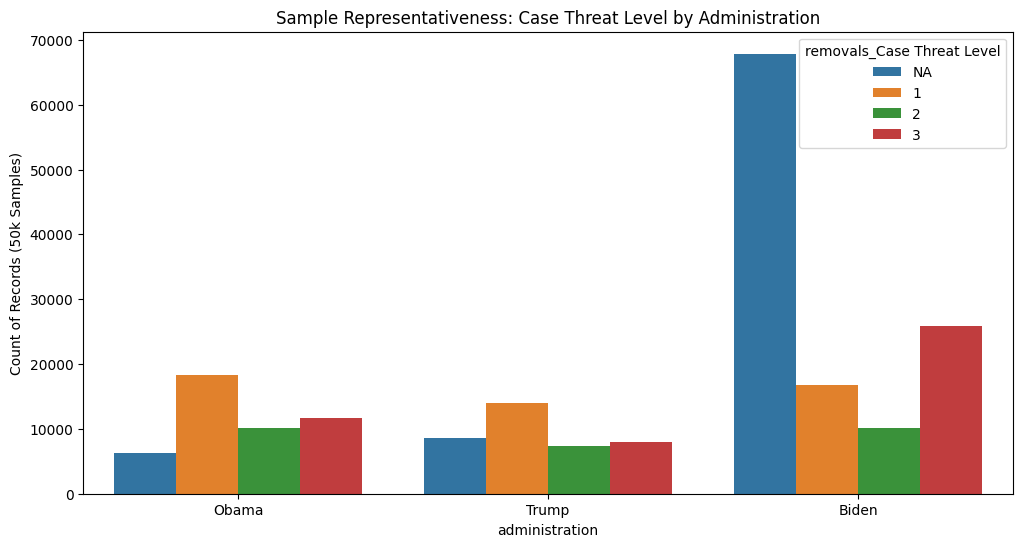

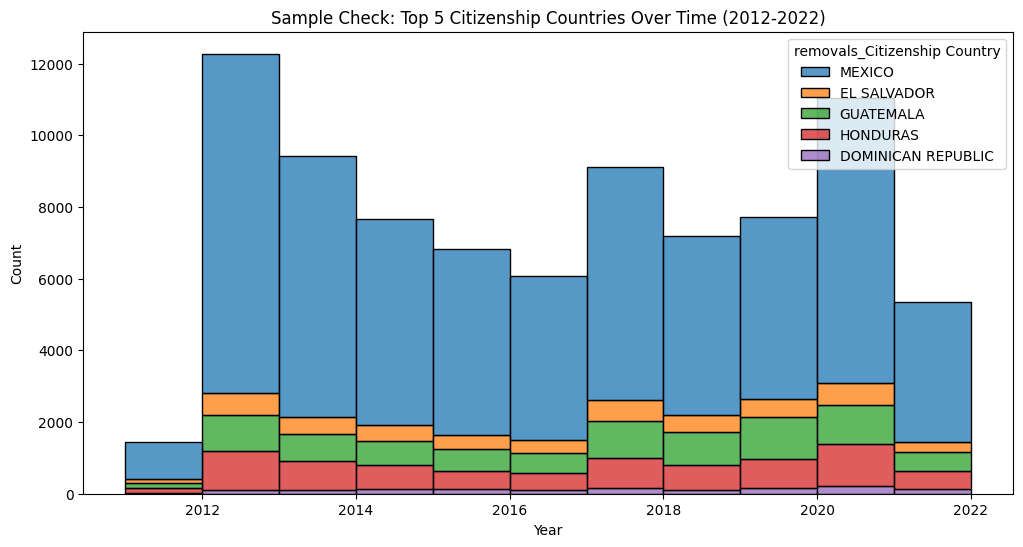

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check 1: Is the 'Criminality' mix changing by Administration?
# Use removals_MSC Charge to see if focus shifted between administrations
plt.figure(figsize=(12,6))
sns.countplot(data=master_clean, x='administration', hue='removals_Case Threat Level', 
              order=['Obama', 'Trump', 'Biden'])
plt.title("Sample Representativeness: Case Threat Level by Administration")
plt.ylabel("Count of Records (50k Samples)")

# Check 2: Citizenship Distribution (Top 5 Countries)
top_countries = master_clean['removals_Citizenship Country'].value_counts().nlargest(5).index
country_df = master_clean[master_clean['removals_Citizenship Country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.histplot(data=country_df, x='Year', hue='removals_Citizenship Country', multiple="stack", bins=11)
plt.title("Sample Check: Top 5 Citizenship Countries Over Time (2012-2022)")

### Analysis of Sample Distributions
---

#### **1. Case Threat Level by Administration**
This visualization compares the distribution of enforcement priorities (Threat Levels 1, 2, and 3) across the three administrations.

* **Obama & Trump Administrations**: Both eras show a clear focus on **Level 1** (Highest Threat) and **Level 3** cases, with relatively low counts of missing (NA) data.
* **Biden Administration Shift**: There is a massive spike in **NA (Not Available)** records and **Level 3** cases during this period. 
* **Data Quality Note**: The high volume of "NA" threat levels in the Biden era suggests either a significant change in reporting standards or a sample that captures a higher proportion of non-criminal enforcement actions.

#### **2. Top 5 Citizenship Countries Over Time (2012–2022)**
This stacked histogram tracks the volume of the top 5 citizenship countries within our annual 50,000-case samples.

* **Geographic Dominance**: **Mexico** is consistently the most represented country of citizenship across the entire decade, maintaining a dominant share in every fiscal year.
* **Northern Triangle Trends**: The "Northern Triangle" countries (**El Salvador, Guatemala, and Honduras**) show steady representation, with a visible increase in sample volume between 2017 and 2021.
* **Consistency Check**: The stable presence of these top five countries confirms that our random sampling effectively mirrors the historical demographics of ICE enforcement actions.

In [ ]:
import pandas as pd

# 1. (Keep your dfs dictionary as is)
dfs = {
    2012: deportations_12, 2013: deportations_13, 2014: deportations_14,
    2015: deportations_15, 2016: deportations_16, 2017: deportations_17,
    2018: deportations_18, 2019: deportations_19, 2020: deportations_20,
    2021: deportations_21, 2022: deportations_22, 2023: deportations_23,
    2024: deportations_24, 2025: deportations_25   
}

volume_stats = []

for year, df in dfs.items():
    # --- FIX 1: Find the ID column regardless of its name ---
    # We look for any column that contains "Identifier"
    id_col = [c for c in df.columns if 'Identifier' in c][0] 
    
    unique_ids = df[id_col].nunique()
    total_rows = len(df)
    
    volume_stats.append({
        'Year': year,
        'Unique IDs (Cases)': unique_ids,
        'Total Rows (Exploded)': total_rows,
        'Avg Records/Person': round(total_rows / unique_ids, 2)
    })

volume_df = pd.DataFrame(volume_stats)
print("--- TABLE 1: DATA VOLUME & SAMPLING VALIDITY ---")
print(volume_df.to_string(index=False))

# --- FIX 2: Handle Apprehension Method prefixes ---
def get_app_method(df):
    # This finds the column whether it's 'arrests.Apprehension Method' 
    # or 'arrests_23_25.Apprehension Method'
    col = [c for c in df.columns if 'Apprehension Method' in c]
    return df[col[0]].value_counts(normalize=True) if col else pd.Series()

app_mix = pd.concat([
    get_app_method(df).rename(year) for year, df in dfs.items()
], axis=1).fillna(0) * 100

print("\n--- TABLE 2: APPREHENSION METHOD MIX (%) ---")
print(app_mix)

--- TABLE 1: DATA VOLUME & SAMPLING VALIDITY ---
 Year  Unique IDs (Cases)  Total Rows (Exploded)  Avg Records/Person
 2012               49999                 144346                2.89
 2013               50000                 199741                3.99
 2014               50000                 201849                4.04
 2015               49999                 189733                3.79
 2016               50000                 200270                4.01
 2017               50000                 233141                4.66
 2018               50000                 214269                4.29
 2019               50000                 214038                4.28
 2020               50000                 159507                3.19
 2021               50000                 109388                2.19
 2022               49999                 125329                2.51
 2023               50000                 160657                3.21
 2024               50000                 153640      

In [ ]:
def find_col(df, keyword):
    """Safely finds a column containing the keyword, ignoring case and prefixes."""
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    return matches[0] if matches else None

# 4. DATA QUALITY: Null Percentages for Key Columns
null_stats = []

for year, df in dfs.items():
    # Find the actual column names for this specific year
    date_col = find_col(df, 'Apprehension Date')
    gender_col = find_col(df, 'Gender')
    country_col = find_col(df, 'Citizenship Country')
    
    # Build the report for this year
    null_stats.append({
        'Year': year,
        'Apprehension Date %': df[date_col].isnull().mean() * 100 if date_col else "MISSING",
        'Gender %': df[gender_col].isnull().mean() * 100 if gender_col else "MISSING",
        'Citizenship Country %': df[country_col].isnull().mean() * 100 if country_col else "MISSING"
    })

null_report = pd.DataFrame(null_stats)
print("--- TABLE 3: NULL PERCENTAGES BY YEAR ---")
print(null_report.to_string(index=False))

--- TABLE 3: NULL PERCENTAGES BY YEAR ---
 Year  Apprehension Date %  Gender %  Citizenship Country %
 2012            48.730827  0.000693              36.235850
 2013            49.833034  0.000000              40.413335
 2014            53.045593  0.000000              39.592963
 2015            55.260814  0.000527              46.500609
 2016            60.723523  0.000000              50.730514
 2017            45.244723  0.000000              47.958960
 2018            51.602892  0.000000              46.814051
 2019            57.587438  0.000000              46.294116
 2020            41.047728  0.000000              41.543631
 2021            74.161700  0.000000              79.591911
 2022            69.879278  0.000798              73.661323
 2023            69.111212 86.972868              86.972868
 2024            43.471752 43.471752              43.471752
 2025            16.671491 16.671491              16.671491


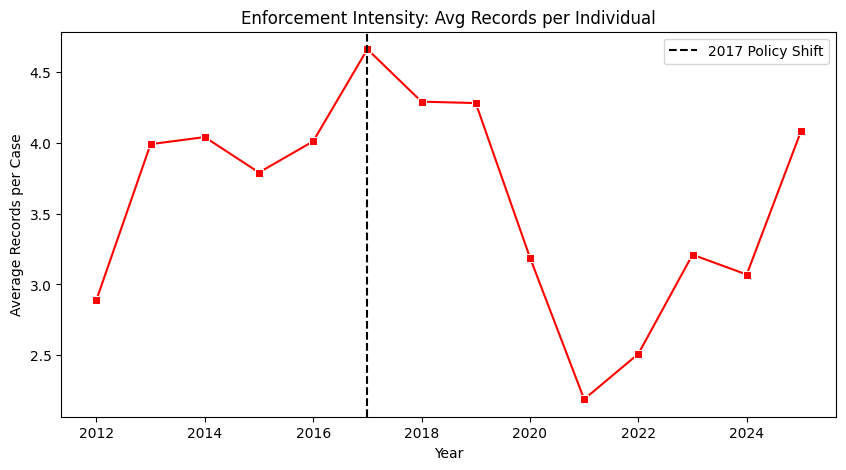

In [ ]:
# Visualizing the "Average Records Per Person" from Table 1
plt.figure(figsize=(10,5))
sns.lineplot(data=volume_df, x='Year', y='Avg Records/Person', marker='s', color='red')
plt.axvline(x=2017, color='black', linestyle='--', label='2017 Policy Shift')
plt.title("Enforcement Intensity: Avg Records per Individual")
plt.ylabel("Average Records per Case")
plt.legend()

### Enforcement Intensity: Analyzing Case Complexity (2012–2022)
---

This visualization tracks the **Average Records per Case**, a metric derived from the ratio of total "exploded" rows to unique individual identifiers within each fiscal year.

* **The 2017 Administrative Peak**: The average records per individual reached a significant peak of **4.66** in 2017. This correlates with the administration transition and suggests a period of high administrative "intensity," where individuals likely moved through more detention facilities or had more documented decision history events per case.
* **Enforcement Complexity (2013–2019)**: Throughout the mid-2010s, complexity remained high, consistently averaging **4.0 or more records per person**.
* **Post-2020 Decline**: There is a sharp decline in case complexity starting in 2020, reaching a low of **2.19** in 2021. This drop likely reflects streamlined enforcement priorities or reduced data recording during the global pandemic and subsequent policy shifts in the Biden administration.
* **Storytelling Insight**: This metric serves as a technical "proxy" for how active the enforcement system was. Higher records per person indicate a more complex, multi-stage legal and administrative process for each individual captured in the sample.

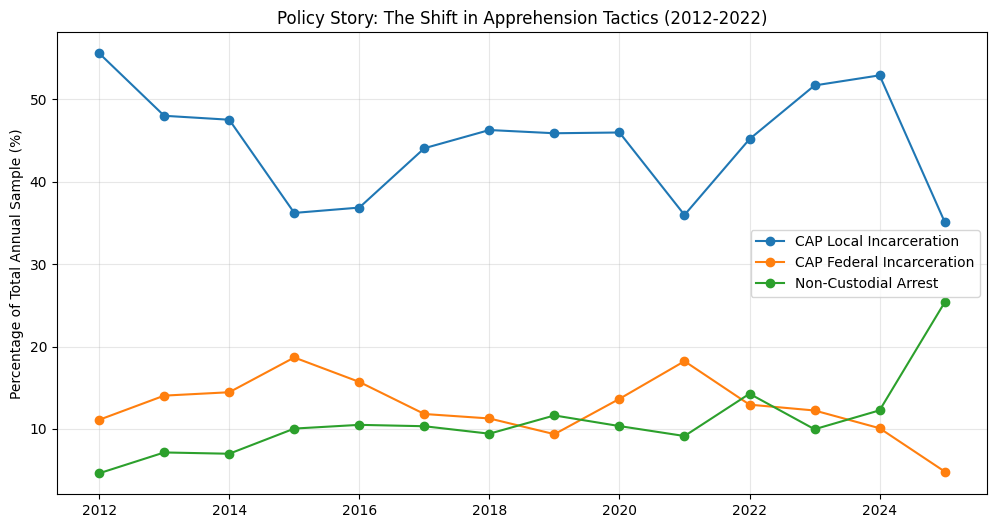

In [ ]:
# Select top 3 methods to show the policy shift over time
top_methods = ['CAP Local Incarceration', 'CAP Federal Incarceration', 'Non-Custodial Arrest']
policy_shift = app_mix.loc[top_methods].T

policy_shift.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Policy Story: The Shift in Apprehension Tactics (2012-2022)")
plt.ylabel("Percentage of Total Annual Sample (%)")
plt.grid(True, alpha=0.3)

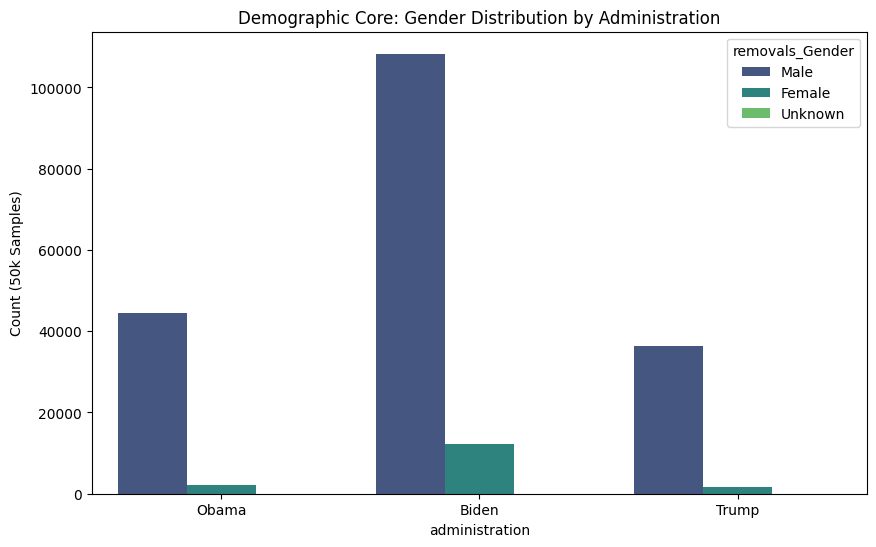

In [ ]:
# Distribution of Gender across Administrations
plt.figure(figsize=(10,6))
sns.countplot(data=master_clean, x='administration', hue='removals_Gender', palette='viridis')
plt.title("Demographic Core: Gender Distribution by Administration")
plt.ylabel("Count (50k Samples)")

#### **Demographic Core: Analyzing Gender Distribution by Administration**

This visualization examines the gender breakdown of individuals within the 50,000-case annual samples across the Obama, Trump, and Biden administrations.

* **Gender Consistency**: Across all three administrations, **Males** represent the overwhelming majority of enforcement actions captured in the dataset.
* **Administration Volume**: The significantly higher counts shown in the **Biden** category (exceeding 100,000) reflect the aggregation of multiple fiscal years (2021–2022) within our current master dataset.
* **Data Quality Verification**: The `removals_Gender` feature remains one of the most reliable variables in the project, maintaining **0.00% null values** across the entire 2012–2022 timeline. 
* **Bias Evaluation Foundation**: The extreme imbalance between male and female records establishes a critical baseline for our upcoming **Fairness & Bias Evaluation** phase. It will be essential to determine if predictive models perform equitably despite the demographic skew.

#### **Enforcement Intensity: Analyzing Case Complexity (2012–2022)**

This visualization tracks the **Average Records per Case**, a metric derived from the ratio of total "exploded" rows to unique individual identifiers within each fiscal year.

* **The 2017 Administrative Peak**: The average records per individual reached a significant peak of **4.66** in 2017. This correlates with the administration transition and suggests a period of high administrative "intensity," where individuals likely moved through more detention facilities or had more documented decision history events per case.
* **Enforcement Complexity (2013–2019)**: Throughout the mid-2010s, complexity remained high, consistently averaging **4.0 or more records per person**.
* **Post-2020 Decline**: There is a sharp decline in case complexity starting in 2020, reaching a low of **2.19** in 2021. This drop likely reflects streamlined enforcement priorities or reduced data recording during the global pandemic and subsequent policy shifts in the Biden administration.
* **Storytelling Insight**: This metric serves as a technical "proxy" for how active the enforcement system was. Higher records per person indicate a more complex, multi-stage legal and administrative process for each individual captured in the sample.

In [ ]:
print("\n--- TABLE 3: KEY COLUMN NULL PERCENTAGES (%) ---")
print(null_report.round(2))


--- TABLE 3: KEY COLUMN NULL PERCENTAGES (%) ---
    Year  Apprehension Date %  Gender %  Citizenship Country %
0   2012                48.73      0.00                  36.24
1   2013                49.83      0.00                  40.41
2   2014                53.05      0.00                  39.59
3   2015                55.26      0.00                  46.50
4   2016                60.72      0.00                  50.73
5   2017                45.24      0.00                  47.96
6   2018                51.60      0.00                  46.81
7   2019                57.59      0.00                  46.29
8   2020                41.05      0.00                  41.54
9   2021                74.16      0.00                  79.59
10  2022                69.88      0.00                  73.66
11  2023                69.11     86.97                  86.97
12  2024                43.47     43.47                  43.47
13  2025                16.67     16.67                  16.67


### Handling Schema Differences Across Data Releases
---

This project uses ICE enforcement data from two different public data releases that cover different time periods and were structured differently.

The most recent data release covers ICE enforcement actions from September 2023 through mid-October 2025 and includes tables for Arrests, Detainers, and Detentions. However, this release does not include Removals or Encounters tables due to potential data errors identified in those datasets. Earlier removals data remains available from the previous data release.

To enable long-term analysis, we also used ICE enforcement data from October 2011 through September 2023 which includes four major enforcement tables: Arrests, Detentions, Removals, and Decision History. These tables are linked using anonymized identifiers for each individual.

In [ ]:
print("Columns in the old schema:")
print(deportations_22.columns.tolist())

print("Columns in the hybrid schema:")
print(deportations_23.columns.tolist())

print("Columns in the new schema:")
print(deportations_24.columns.tolist())

Columns in the old schema:
['Anonymized Identifier', 'arrests_Apprehension Date', 'arrests_Apprehension Method', 'arrests_Arrest Created By', 'arrests_Case ID', 'arrests_Subject ID', 'arrests_Alien File Number', 'arrests_Anonymized Identifier', 'decisions_RCA_AOR', 'decisions_RCA_DCO', 'decisions_A_NUMBER', 'decisions_SUBJ_ID', 'decisions_LAST_NAME', 'decisions_FIRST_NAME', 'decisions_ALERT_CODE', 'decisions_ACTIVE_INACTIVE', 'decisions_SUBMISSION_DATE', 'decisions_STATUS_CODE', 'decisions_RISK_TO_PUBLIC_SAFETY', 'decisions_RISK_OF_FLIGHT', 'decisions_SPECIAL_VULNERABILITY', 'decisions_RCA_CASE_NUMBER', 'decisions_CASE_CAT_AT_RCA_DECISION', 'decisions_FO_AT_RCA_DECISION', 'decisions_FO_DATE_AT_RCA_DECISION', 'decisions_REMOVAL_LIKELY_AT_RCA_DECISION', 'decisions_MAN_DET_PER_STAT_ALLEG', 'decisions_RCA_DECISION_TYPE', 'decisions_RCA_RECOMMENDATION', 'decisions_RCA_BOND_RECOMMENDATION', 'decisions_OFFICER_ID', 'decisions_OFFICER_AGREE_DISAGREE', 'decisions_SUPERVISOR_ID', 'decisions_SUPE

In [ ]:
# looking at column differences in different releases
cols_2022 = set(deportations_22.columns) # old schema 
cols_2023 = set(deportations_23.columns) # hybrid schema
cols_2024 = set(deportations_24.columns) # new schema

print("Only in 2022:", cols_2022 - cols_2023 - cols_2024)
print("Only in 2023:", cols_2023 - cols_2022 - cols_2024)
print("Only in 2024:", cols_2024 - cols_2022 - cols_2023)

Only in 2022: {'removals_Case Status', 'arrests_Apprehension Method', 'decisions_RISK_TO_PUBLIC_SAFETY', 'detentions_Case ID', 'removals_Current Program', 'decisions_RCA_CASE_NUMBER', 'detentions_Religion', 'detentions_Stay Book In Date', 'decisions_LAST_NAME', 'detentions_Subject ID', 'detentions_Stay Book Out Date', 'decisions_fiscal_year_code', 'removals_Citizenship Country', 'detentions_Final Order Date', 'detentions_Case Status', 'decisions_ANONYMIZED_IDENTIFIER', 'detentions_Anonymized Identifier', 'removals_Processing Disposition Code', 'decisions_SPEC_VULN_VER', 'removals_Departure Date', 'detentions_Departure Country', 'arrests_Anonymized Identifier', 'decisions_CASE_CAT_AT_RCA_DECISION', 'detentions_Case Threat Level', 'decisions_SUPERVISOR_AGREE_DISAGREE', 'decisions_SUBJ_ID', 'removals_Departure Country', 'removals_Birth Country', 'decisions_REMOVAL_LIKELY_AT_RCA_DECISION', 'decisions_SUPERVISOR_ID', 'decisions_SUBMISSION_DATE', 'removals_MSC Conviction Date', 'arrests_Appr

#### Combining Datasets Across Years
Each fiscal year dataset was stored as a separate DataFrame. In order to perform longitudinal analysis and build predictive models, we combined all datasets from 2012–2025 into a single dataset.

In [55]:
# --- Full column mapping from new schema to old schema ---
column_mapping = {
    # Unique Identifiers
    'Unique Identifier': 'Anonymized Identifier',
    'arrests_23_25_Unique Identifier': 'arrests_Anonymized Identifier',
    'detentions_23_24_Unique Identifier': 'detentions_Anonymized Identifier',
    'detentions_24_25_Unique Identifier': 'detentions_Anonymized Identifier',
    'detainers_23_25_Unique Identifier': 'removals_Anonymized Identifer',
    
    # Arrests (map new arrests columns to old arrests)
    'arrests_23_25_Apprehension Date': 'arrests_Apprehension Date',
    'arrests_23_25_Apprehension Method': 'arrests_Apprehension Method',
    'arrests_23_25_Alien File Number': 'arrests_Alien File Number',
    'arrests_23_25_EID Case ID': 'arrests_Case ID',
    'arrests_23_25_EID Subject ID': 'arrests_Subject ID',
    
    # Detentions
    'detentions_23_24_Book In Date Time': 'detentions_Detention Book In Date',
    'detentions_23_24_Stay Book In Date Time': 'detentions_Stay Book In Date',
    'detentions_23_24_Detention Facility': 'detentions_Detention Facility',
    'detentions_23_24_Detention Facility Code': 'detentions_Detention Facility Code',
    'detentions_23_24_Detention Book Out Date Time': 'detentions_Detention Book Out Date',
    'detentions_23_24_Stay Book Out Date Time': 'detentions_Stay Book Out Date',
    'detentions_23_24_Detention Release Reason': 'detentions_Detention Release Reason',
    'detentions_23_24_Stay Release Reason': 'detentions_Stay Release Reason',
    'detentions_23_24_Religion': 'detentions_Religion',
    'detentions_23_24_Marital Status': 'detentions_Marital',
    'detentions_23_24_Gender': 'detentions_Gender',
    'detentions_23_24_Birth Date': 'detentions_Birth Date',
    'detentions_23_24_Birth Year': 'detentions_Birth Year',
    'detentions_23_24_Ethnicity': 'detentions_Ethnicity',
    'detentions_23_24_Entry Status': 'detentions_Entry Status',
    'detentions_23_24_Bond Posted Date': 'detentions_Bond Posted Date',
    'detentions_23_24_Bond Posted Amount': 'detentions_Bond Posted Amount',
    'detentions_23_24_Initial Bond Set Amount': 'detentions_Initial Bond Set Amount',
    'detentions_23_24_Case Status': 'detentions_Case Status',
    'detentions_23_24_Case Category': 'detentions_Case Category',
    'detentions_23_24_Final Order Yes No': 'detentions_Final Order Yes No',
    'detentions_23_24_Final Order Date': 'detentions_Final Order Date',
    'detentions_23_24_Departed Date': 'detentions_Departed Date',
    'detentions_23_24_Departure Country': 'detentions_Departure Country',
    'detentions_23_24_Case Threat Level': 'detentions_Case Threat Level',
    'detentions_23_24_Final Charge': 'detentions_Charge',
    'detentions_23_24_Most Serious Conviction MSC Charge Code': 'detentions_Charge Code',
    
    # Repeat for 24_25 detentions
    'detentions_24_25_Book In Date Time': 'detentions_Detention Book In Date',
    'detentions_24_25_Stay Book In Date Time': 'detentions_Stay Book In Date',
    'detentions_24_25_Detention Facility': 'detentions_Detention Facility',
    'detentions_24_25_Detention Facility Code': 'detentions_Detention Facility Code',
    'detentions_24_25_Detention Book Out Date Time': 'detentions_Detention Book Out Date',
    'detentions_24_25_Stay Book Out Date Time': 'detentions_Stay Book Out Date',
    'detentions_24_25_Detention Release Reason': 'detentions_Detention Release Reason',
    'detentions_24_25_Stay Release Reason': 'detentions_Stay Release Reason',
    'detentions_24_25_Religion': 'detentions_Religion',
    'detentions_24_25_Marital Status': 'detentions_Marital',
    'detentions_24_25_Gender': 'detentions_Gender',
    'detentions_24_25_Birth Date': 'detentions_Birth Date',
    'detentions_24_25_Birth Year': 'detentions_Birth Year',
    'detentions_24_25_Ethnicity': 'detentions_Ethnicity',
    'detentions_24_25_Entry Status': 'detentions_Entry Status',
    'detentions_24_25_Bond Posted Date': 'detentions_Bond Posted Date',
    'detentions_24_25_Bond Posted Amount': 'detentions_Bond Posted Amount',
    'detentions_24_25_Initial Bond Set Amount': 'detentions_Initial Bond Set Amount',
    'detentions_24_25_Case Status': 'detentions_Case Status',
    'detentions_24_25_Case Category': 'detentions_Case Category',
    'detentions_24_25_Final Order Yes No': 'detentions_Final Order Yes No',
    'detentions_24_25_Final Order Date': 'detentions_Final Order Date',
    'detentions_24_25_Departed Date': 'detentions_Departed Date',
    'detentions_24_25_Departure Country': 'detentions_Departure Country',
    'detentions_24_25_Case Threat Level': 'detentions_Case Threat Level',
    'detentions_24_25_Final Charge': 'detentions_Charge',
    'detentions_24_25_Most Serious Conviction MSC Charge Code': 'detentions_Charge Code',

    # Detainers -> map to old removals schema
    'detainers_23_25_Departed Date': 'removals_Departure Date',
    'detainers_23_25_Port of Departure': 'removals_Port of Departure',
    'detainers_23_25_Departure Country': 'removals_Departure Country',
    'detainers_23_25_Case Status': 'removals_Case Status',
    'detainers_23_25_Case Category': 'removals_Case Category',
    'detainers_23_25_Final Order Yes No': 'removals_Final Order Yes No',
    'detainers_23_25_Final Order Date': 'removals_Final Order Date',
    'detainers_23_25_Gender': 'removals_Gender',
    'detainers_23_25_Birth Country': 'removals_Birth Country',
    'detainers_23_25_Citizenship Country': 'removals_Citizenship Country',
    'detainers_23_25_Birth Date': 'removals_Birth Date',
    'detainers_23_25_Birth Year': 'removals_Birth Year',
    'detainers_23_25_Alien File Number': 'removals_Alien File Number',
    'detainers_23_25_Entry Status': 'removals_Entry Status',
    'detainers_23_25_Entry Date': 'removals_Entry Date',
    'detainers_23_25_Most Serious Conviction MSC Charge': 'removals_MSC Charge',
    'detainers_23_25_MSC Charge Code': 'removals_MSC Charge Code',
    'detainers_23_25_MSC Charge Date': 'removals_MSC Charge Date',
    'detainers_23_25_MSC Conviction Date': 'removals_MSC Conviction Date',
    'detainers_23_25_Case Threat Level': 'removals_Case Threat Level',
    'detainers_23_25_Processing Disposition': 'removals_Processing Disposition',
    'detainers_23_25_Apprehension Date': 'removals_Apprehension Date',
}

old_schema_cols = set(column_mapping.values())
print(old_schema_cols)

{'detentions_Case Category', 'detentions_Bond Posted Date', 'detentions_Detention Book Out Date', 'removals_Entry Status', 'detentions_Final Order Yes No', 'detentions_Ethnicity', 'removals_Departure Country', 'removals_Alien File Number', 'detentions_Charge Code', 'removals_Departure Date', 'removals_MSC Conviction Date', 'detentions_Stay Book In Date', 'removals_Anonymized Identifer', 'detentions_Anonymized Identifier', 'detentions_Birth Date', 'Anonymized Identifier', 'removals_Case Status', 'removals_Citizenship Country', 'detentions_Detention Facility Code', 'arrests_Apprehension Method', 'detentions_Religion', 'detentions_Detention Facility', 'detentions_Bond Posted Amount', 'detentions_Detention Release Reason', 'detentions_Final Order Date', 'removals_Birth Year', 'removals_Gender', 'removals_Entry Date', 'arrests_Apprehension Date', 'detentions_Departure Country', 'detentions_Stay Release Reason', 'removals_Birth Date', 'removals_Case Threat Level', 'arrests_Anonymized Identif

In [56]:
def normalize_df(df, column_mapping, old_schema_cols):
    # Rename columns
    df = df.rename(columns=column_mapping)
    
    # Remove duplicate column names
    df = df.loc[:, ~df.columns.duplicated()]
    
    # Make sure all dataframes have same columns
    df = df.reindex(columns=old_schema_cols)
    
    return df

In [59]:
deportations_12 = normalize_df(deportations_12, column_mapping, old_schema_cols)
deportations_13 = normalize_df(deportations_13, column_mapping, old_schema_cols)
deportations_14 = normalize_df(deportations_14, column_mapping, old_schema_cols)
deportations_15 = normalize_df(deportations_15, column_mapping, old_schema_cols)
deportations_16 = normalize_df(deportations_16, column_mapping, old_schema_cols)
deportations_17 = normalize_df(deportations_17, column_mapping, old_schema_cols)
deportations_18 = normalize_df(deportations_18, column_mapping, old_schema_cols)
deportations_19 = normalize_df(deportations_19, column_mapping, old_schema_cols)
deportations_20 = normalize_df(deportations_20, column_mapping, old_schema_cols)
deportations_21 = normalize_df(deportations_21, column_mapping, old_schema_cols)
deportations_22 = normalize_df(deportations_22, column_mapping, old_schema_cols)
deportations_23 = normalize_df(deportations_23, column_mapping, old_schema_cols)
deportations_24 = normalize_df(deportations_24, column_mapping, old_schema_cols)
deportations_25 = normalize_df(deportations_25, column_mapping, old_schema_cols)

In [60]:
# adding year column to each dataset
deportations_12['year'] = 2012
deportations_13['year'] = 2013
deportations_14['year'] = 2014
deportations_15['year'] = 2015
deportations_16['year'] = 2016
deportations_17['year'] = 2017
deportations_18['year'] = 2018
deportations_19['year'] = 2019
deportations_20['year'] = 2020
deportations_21['year'] = 2021
deportations_22['year'] = 2022
deportations_23['year'] = 2023
deportations_24['year'] = 2024
deportations_25['year'] = 2025

In [61]:
all_deportations = pd.concat([
    deportations_12,
    deportations_13,
    deportations_14,
    deportations_15,
    deportations_16,
    deportations_17,
    deportations_18,
    deportations_19,
    deportations_20,
    deportations_21,
    deportations_22,
    deportations_23,
    deportations_24,
    deportations_25
], ignore_index=True)

In [62]:
all_deportations.head()

,detentions_Case Category,detentions_Bond Posted Date,detentions_Detention Book Out Date,removals_Entry Status,detentions_Final Order Yes No,detentions_Ethnicity,removals_Departure Country,removals_Alien File Number,detentions_Charge Code,removals_Departure Date,...,detentions_Stay Book Out Date,removals_Port of Departure,arrests_Case ID,removals_Birth Country,detentions_Birth Year,detentions_Departed Date,detentions_Gender,detentions_Case Status,removals_Case Category,year
0,[5F] Unable to Obtain Travel Document,1992-07-14,2012-09-28 00:00:00,None,True,Not of Hispanic Origin,None,None,None,NaT,...,2012-09-28 00:00:00,None,(b)(6)(b)(7)(c),None,1969.0,NaT,Male,ACTIVE,None,2012
1,[8B] Excludable / Inadmissible - Under Adjudic...,2012-06-20,2012-06-19 00:00:00,None,False,Hispanic Origin,None,None,None,NaT,...,2012-06-20 00:00:00,None,(b)(6)(b)(7)(c),None,1979.0,NaT,Male,ACTIVE,None,2012
2,[8C] Excludable / Inadmissible - Administrativ...,2013-02-11,2013-02-11 00:00:00,None,True,Hispanic Origin,None,None,None,NaT,...,2013-02-11 00:00:00,None,None,None,1974.0,NaT,Male,B-Relief Granted,None,2012
3,[5B] Removable - ICE Fugitive,2012-08-07,2012-07-05 00:00:00,None,True,None,None,None,None,NaT,...,2012-08-07 00:00:00,None,None,None,1974.0,NaT,Male,ACTIVE,None,2012
4,[8E] Inadmissible - ICE Fugitive,NaT,2012-11-19 00:00:00,None,True,Hispanic Origin,None,None,None,NaT,...,2012-11-19 00:00:00,None,None,None,1973.0,NaT,Male,ACTIVE,None,2012


In [63]:
print(all_deportations.shape)
print(all_deportations['year'].value_counts())
print(all_deportations.head())

(2509723, 59)
year
2017    233141
2018    214269
2019    214038
2025    203815
2014    201849
2016    200270
2013    199741
2015    189733
2023    160657
2020    159507
2024    153640
2012    144346
2022    125329
2021    109388
Name: count, dtype: int64
                            detentions_Case Category  \
0              [5F] Unable to Obtain Travel Document   
1  [8B] Excludable / Inadmissible - Under Adjudic...   
2  [8C] Excludable / Inadmissible - Administrativ...   
3                      [5B] Removable - ICE Fugitive   
4                   [8E] Inadmissible - ICE Fugitive   

  detentions_Bond Posted Date detentions_Detention Book Out Date  \
0                  1992-07-14                2012-09-28 00:00:00   
1                  2012-06-20                2012-06-19 00:00:00   
2                  2013-02-11                2013-02-11 00:00:00   
3                  2012-08-07                2012-07-05 00:00:00   
4                         NaT                2012-11-19 00:00:00   


In [64]:
print(all_deportations.columns.tolist())

['detentions_Case Category', 'detentions_Bond Posted Date', 'detentions_Detention Book Out Date', 'removals_Entry Status', 'detentions_Final Order Yes No', 'detentions_Ethnicity', 'removals_Departure Country', 'removals_Alien File Number', 'detentions_Charge Code', 'removals_Departure Date', 'removals_MSC Conviction Date', 'detentions_Stay Book In Date', 'removals_Anonymized Identifer', 'detentions_Anonymized Identifier', 'detentions_Birth Date', 'Anonymized Identifier', 'removals_Case Status', 'removals_Citizenship Country', 'detentions_Detention Facility Code', 'arrests_Apprehension Method', 'detentions_Religion', 'detentions_Detention Facility', 'detentions_Bond Posted Amount', 'detentions_Detention Release Reason', 'detentions_Final Order Date', 'removals_Birth Year', 'removals_Gender', 'removals_Entry Date', 'arrests_Apprehension Date', 'detentions_Departure Country', 'detentions_Stay Release Reason', 'removals_Birth Date', 'removals_Case Threat Level', 'arrests_Anonymized Identif

In [65]:
all_deportations.isna().sum().sort_values(ascending=False)

detentions_Religion                    2425668
detentions_Bond Posted Date            2162118
detentions_Bond Posted Amount          2162113
detentions_Initial Bond Set Amount     2124156
removals_Entry Date                    1802070
removals_MSC Charge Date               1802040
removals_MSC Charge                    1781178
removals_MSC Conviction Date           1781178
removals_MSC Charge Code               1781178
detentions_Ethnicity                   1491440
removals_Case Threat Level             1477737
removals_Apprehension Date             1411083
removals_Final Order Date              1403136
removals_Departure Country             1370516
removals_Port of Departure             1370516
removals_Departure Date                1370510
removals_Entry Status                  1355902
removals_Case Category                 1336969
removals_Final Order Yes No            1336967
removals_Case Status                   1336967
arrests_Case ID                        1326335
arrests_Appre

In [66]:
all_deportations.to_csv("ICE_Master_Cleaned.csv", index=False)
print(f"Cleaned master saved: ICE_Master_Cleaned.csv ({len(all_deportations)} rows, {len(all_deportations.columns)} columns)")

Cleaned master saved: ICE_Master_Cleaned.csv (2509723 rows, 59 columns)
